# Credit Risk & Risk Management Strategy

### 1. Load packages and dataset

Credit cards have become an essential part of the modern financial system, allowing customers to make purchases and payments in advance. However, this convenience is also associated with credit default risk, as some customers may spend beyond their repayment capacity and fail to pay back their debt on time.

This research is based on a dataset of 25,000 customers and aims to identify the trends and patterns behind credit card defaults. In addition, the project develops a predictive tool that enables users to estimate the probability of customer default in the following month with only a few clicks. The findings of this research also provide practical strategies for reducing default risk and improving credit risk management.

In [142]:
# Core Data and Numerical Tools
import numpy as np # scientific computing with arrays
import pandas as pd # data structures and analysis tools
from scipy.stats import randint, uniform # statistical distributions for hyperparameter sampling
import random

# Visualization Tools
import matplotlib.pyplot as plt # general purpose data visualization
import seaborn as sns # statistical data visualization

# Preprocessing and Utilities
from sklearn.model_selection import train_test_split # split data into train and validation subsets
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder # standardize features and encode categorical features
from sklearn.compose import ColumnTransformer # column transformation
from sklearn.pipeline import Pipeline # data processing and modeling steps
from sklearn.feature_selection import VarianceThreshold # remove features with low variance
from collections import Counter
from imblearn.combine import SMOTETomek

# Models
from sklearn.tree import plot_tree, DecisionTreeClassifier # Decision Tree
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier # Gradient Boost and Random Forest
from xgboost import XGBClassifier # XGBoost
from xgboost import plot_importance # visualization of feature importance scores
from sklearn.model_selection import GridSearchCV, StratifiedKFold, RandomizedSearchCV # tuning and cross-validation tools
from tensorflow import keras
from tensorflow.keras.models import Sequential # Neuron Network
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import tensorflow as tf
# Evaluation Metrics and Display
from sklearn.metrics import mean_squared_error, roc_curve, auc, r2_score, accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, make_scorer # model performance evaluation
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, RocCurveDisplay # output analysis and display
# Save model for UI design
import joblib

In [2]:
df = pd.read_csv(r"C:\Users\nguye\Downloads\train_dataset_creditscoring.csv")

### 2. Data exploration

In [3]:
df.shape

(25247, 27)

In [4]:
df.describe()

,Customer_ID,marriage,sex,education,LIMIT_BAL,age,pay_0,pay_2,pay_3,pay_4,...,Bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,AVG_Bill_amt,PAY_TO_BILL_ratio,next_month_default
count,25247.000000,25247.000000,25247.000000,25247.000000,25247.000000,25121.000000,25247.000000,25247.000000,25247.000000,25247.000000,...,25247.000000,25247.000000,2.524700e+04,25247.000000,25247.000000,25247.000000,25247.000000,25247.000000,25247.000000,25247.000000
mean,17640.000000,1.551907,0.604111,1.852101,168342.060443,35.438199,-0.042857,-0.159544,-0.190359,-0.241415,...,38806.221029,5718.624966,6.047352e+03,5288.910651,4865.960834,4906.766828,5270.499287,44859.647485,0.362962,0.190399
std,7288.325459,0.522629,0.489050,0.797379,129892.784807,9.174998,1.099315,1.173990,1.172636,1.146753,...,59182.792531,16806.842125,2.400962e+04,17851.879609,15979.116544,15860.726852,17960.816915,62819.226119,5.047206,0.392624
min,5017.000000,0.000000,0.000000,0.000000,10000.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,-56043.170000,-546.930000,0.000000
25%,11328.500000,1.000000,0.000000,1.000000,50000.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,1241.710000,999.985000,9.219100e+02,399.990000,300.150000,262.365000,130.070000,4858.670000,0.040000,0.000000
50%,17640.000000,2.000000,1.000000,2.000000,140000.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,17102.580000,2145.020000,2.026830e+03,1844.300000,1500.100000,1513.790000,1500.040000,21102.830000,0.090000,0.000000
75%,23951.500000,2.000000,1.000000,2.000000,240000.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,49245.195000,5031.150000,5.000190e+03,4600.640000,4014.990000,4099.890000,4018.780000,57136.580000,0.590000,0.000000
max,30263.000000,3.000000,1.000000,6.000000,1000000.000000,79.000000,8.000000,8.000000,8.000000,7.000000,...,961663.620000,873551.980000,1.684259e+06,896040.150000,621000.080000,426529.180000,528666.150000,877313.830000,205.380000,1.000000


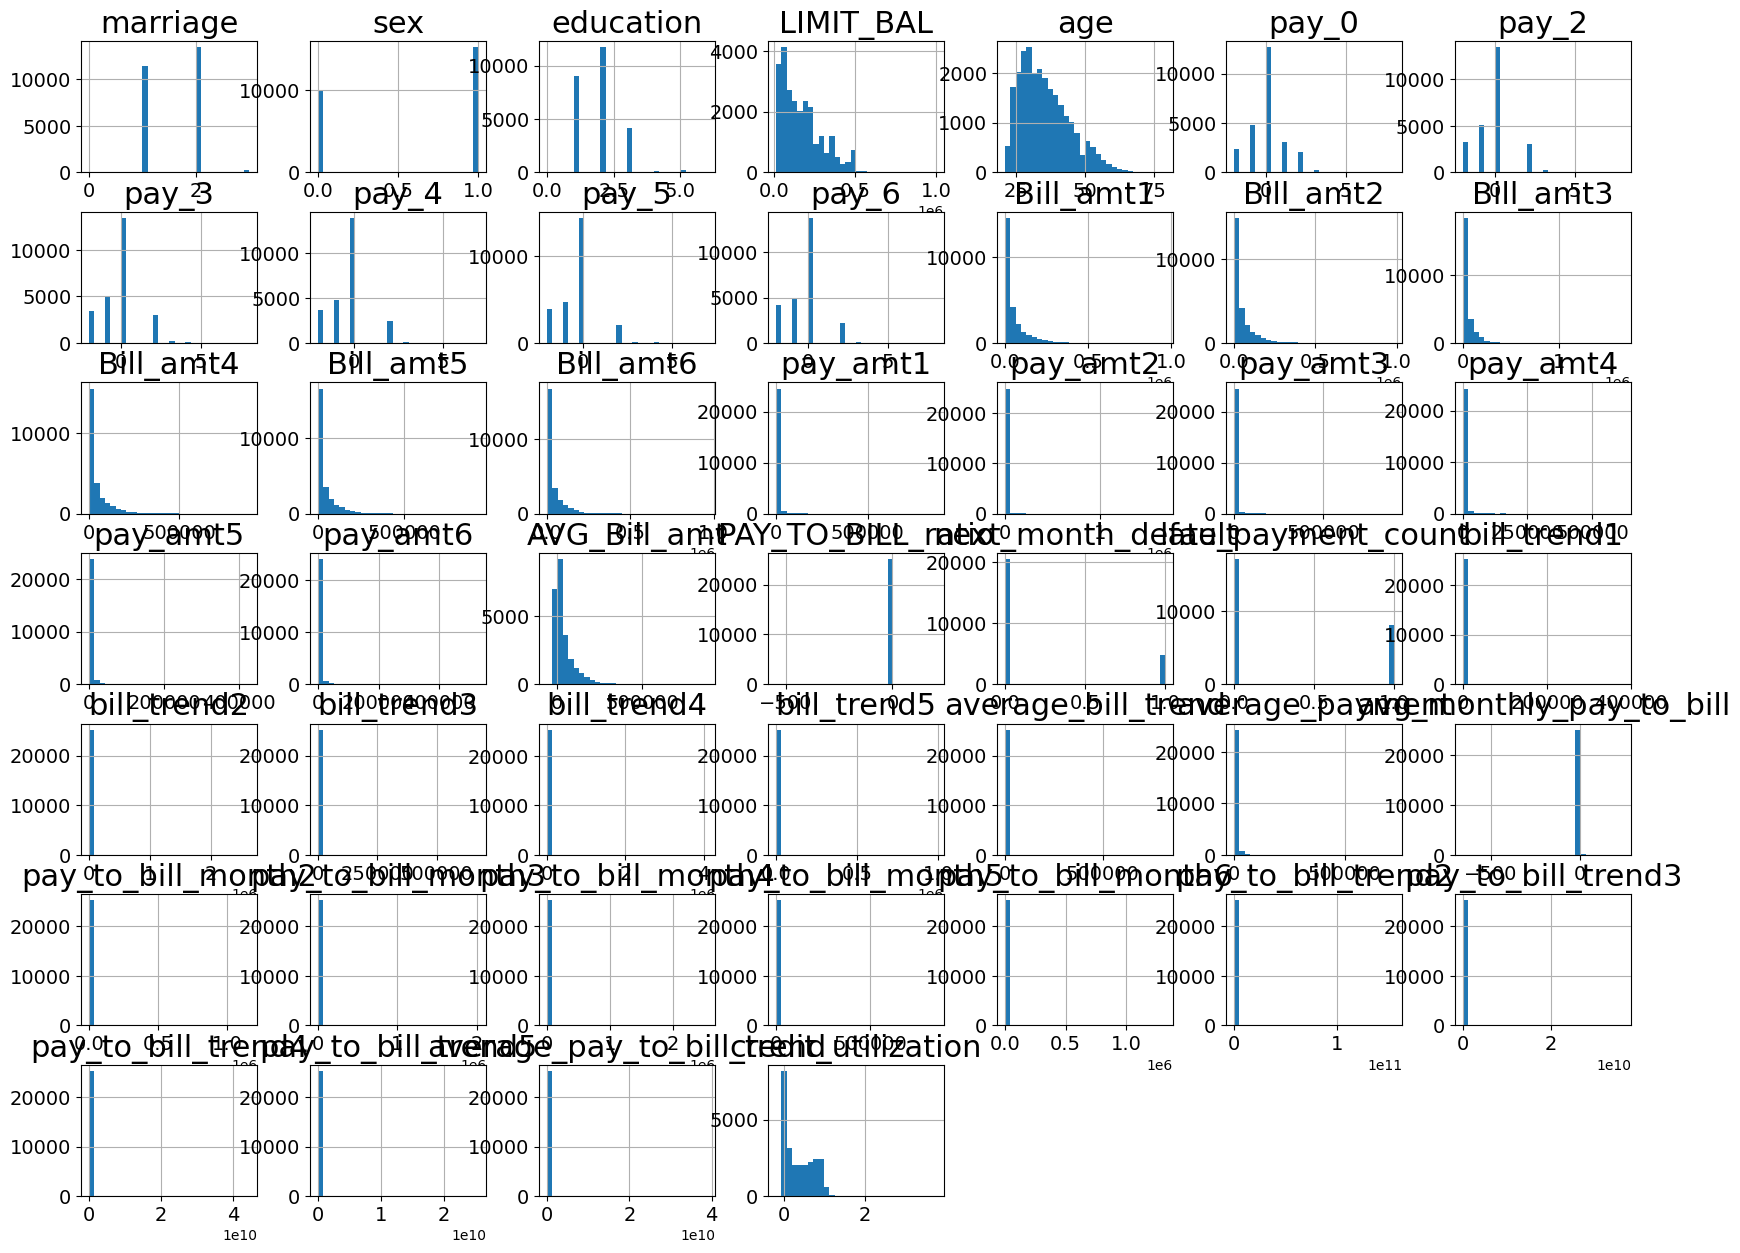

In [54]:
# Histograms
df_plot = df_train.drop(columns=['Customer_ID']) # Drop ID
axes = df_plot.hist(bins = 30, figsize = (20,15),
             xlabelsize=14,   # x-axis label size
            ylabelsize=14)   # y-axis label size

for ax in axes.ravel():
    ax.set_title(ax.get_title(), fontsize=22)   # subplot title
    ax.tick_params(axis='both', labelsize=14)   # tick labels

plt.show()

In [143]:
df.dtypes

Customer_ID             int64
marriage                int64
sex                     int64
education               int64
LIMIT_BAL               int64
age                   float64
pay_0                   int64
pay_2                   int64
pay_3                   int64
pay_4                   int64
pay_5                   int64
pay_6                   int64
Bill_amt1             float64
Bill_amt2             float64
Bill_amt3             float64
Bill_amt4             float64
Bill_amt5             float64
Bill_amt6             float64
pay_amt1              float64
pay_amt2              float64
pay_amt3              float64
pay_amt4              float64
pay_amt5              float64
pay_amt6              float64
AVG_Bill_amt          float64
PAY_TO_BILL_ratio     float64
next_month_default      int64
dtype: object

### 3. Data wrangling

#### 3.1. Checking missing data & filling missing data

In [40]:
# Checking missing data
df.isnull().sum()

Customer_ID             0
marriage                0
sex                     0
education               0
LIMIT_BAL               0
age                   126
pay_0                   0
pay_2                   0
pay_3                   0
pay_4                   0
pay_5                   0
pay_6                   0
Bill_amt1               0
Bill_amt2               0
Bill_amt3               0
Bill_amt4               0
Bill_amt5               0
Bill_amt6               0
pay_amt1                0
pay_amt2                0
pay_amt3                0
pay_amt4                0
pay_amt5                0
pay_amt6                0
AVG_Bill_amt            0
PAY_TO_BILL_ratio       0
next_month_default      0
dtype: int64

In [41]:
# Filling missing ages with the median age of the dataset
median_age = df[["age"]].median()
print(median_age)

age    34.0
dtype: float64


In [42]:
df_train = df.fillna(median_age)

In [43]:
# Check again
df_train.isnull().sum()

Customer_ID           0
marriage              0
sex                   0
education             0
LIMIT_BAL             0
age                   0
pay_0                 0
pay_2                 0
pay_3                 0
pay_4                 0
pay_5                 0
pay_6                 0
Bill_amt1             0
Bill_amt2             0
Bill_amt3             0
Bill_amt4             0
Bill_amt5             0
Bill_amt6             0
pay_amt1              0
pay_amt2              0
pay_amt3              0
pay_amt4              0
pay_amt5              0
pay_amt6              0
AVG_Bill_amt          0
PAY_TO_BILL_ratio     0
next_month_default    0
dtype: int64

#### 3.2. Data wrangling

In [44]:
# Define wrangling steps
def standardization(df_train):
    # Late_payment_count
    df_train["late_payment_count"] = (
        (df_train[[f"pay_{i}" for i in [0, 2, 3, 4, 5, 6]]] >= 1)
        .any(axis=1)
        .astype(int)
    )

    #df_train["minimum_payment_count"] = (
    #    (df_train[[f"pay_{i}" for i in [0, 2, 3, 4, 5, 6]]] == 0)
    #    .any(axis=1)
    #    .astype(int)
    #)

    # Bill trend
    for i in range(1, 6):

        df_train[f"bill_trend{i}"] = np.where(
            df_train[f"Bill_amt{i}"] <= 0,
            1,  # 100%
            (
                (df_train[f"Bill_amt{i+1}"] - df_train[f"Bill_amt{i}"])
                / df_train[f"Bill_amt{i}"]
            )
        )

    df_train["average_bill_trend"] = df_train[
        [f"bill_trend{i}" for i in range(1, 6)]
    ].mean(axis=1)

    # Average payment
    df_train["average_payment"] = df_train[
        [f"pay_amt{i}" for i in range(1, 6)]
    ].mean(axis=1)

    df_train["avg_monthly_pay_to_bill"] = np.where(
        df_train[f"AVG_Bill_amt"] <= 0, 1,
        df_train["average_payment"] / (df_train["AVG_Bill_amt"])
    )

    # Pay to bill ratio
    for i in range(2, 7):

        df_train[f"pay_to_bill_month{i}"] = np.where(
            df_train[f"Bill_amt{i-1}"] <= 0,
            1,
            df_train[f"pay_amt{i}"] / df_train[f"Bill_amt{i-1}"]
        )

    # Trend of pay-to-bill
    for i in range(2, 6):

        df_train[f"pay_to_bill_trend{i}"] = np.where(
            df_train[f"pay_to_bill_month{i}"] == 0,
            1,
            (
                (
                    df_train[f"pay_to_bill_month{i+1}"]
                    - df_train[f"pay_to_bill_month{i}"]
                )
                / df_train[f"pay_to_bill_month{i}"]
            )
        )

    df_train["average_pay_to_bill_trend"] = df_train[
        [f"pay_to_bill_trend{i}" for i in range(2, 6)]
    ].mean(axis=1)


    df_train['credit_utilization'] = (
        df_train['AVG_Bill_amt'] / (df_train['LIMIT_BAL'] + 1)
    )

    return df_train

In [45]:
df_train_clean = standardization(df_train)
df_train_clean.shape

(25247, 47)

#### 3.3. Features defining

In [47]:
# Defines features
X = df_train_clean.drop(columns = ["next_month_default", 'Customer_ID', #'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6',
        'Bill_amt1', 'Bill_amt2', 'Bill_amt3',
        'Bill_amt4', 'Bill_amt5', 'Bill_amt6',
        'pay_amt1', 'pay_amt2', 'pay_amt3',
        'pay_amt4', 'pay_amt5', 'pay_amt6',
         'PAY_TO_BILL_ratio', 'bill_trend1', 'bill_trend2', 'bill_trend3', 'bill_trend4',
       'bill_trend5', 'pay_to_bill_month2',
       'pay_to_bill_month3', 'pay_to_bill_month4', 'pay_to_bill_month5',
        'pay_to_bill_trend2', 'pay_to_bill_trend3',
       'pay_to_bill_trend4', 'pay_to_bill_month6', 'pay_to_bill_trend5','bill_trend1', 'bill_trend2', 'bill_trend3',
       'bill_trend4', 'bill_trend5',])
X.columns

Index(['marriage', 'sex', 'education', 'LIMIT_BAL', 'age', 'pay_0', 'pay_2',
       'pay_3', 'pay_4', 'pay_5', 'pay_6', 'AVG_Bill_amt',
       'late_payment_count', 'average_bill_trend', 'average_payment',
       'avg_monthly_pay_to_bill', 'average_pay_to_bill_trend',
       'credit_utilization'],
      dtype='str')

In [119]:
# Check correlation to avoid multicollinearity
X.corr()

,marriage,sex,education,LIMIT_BAL,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,AVG_Bill_amt,late_payment_count,average_bill_trend,average_payment,avg_monthly_pay_to_bill,average_pay_to_bill_trend,credit_utilization
marriage,1.000000,-0.031876,-0.149530,-0.102085,-0.413662,0.020694,0.023440,0.031506,0.031848,0.031855,0.031112,-0.023068,0.002214,-0.006318,-0.008207,-0.006554,0.006177,0.048741
sex,-0.031876,1.000000,0.019173,0.023435,-0.089775,-0.051158,-0.066689,-0.060550,-0.060808,-0.052867,-0.043636,-0.023827,-0.021602,0.005914,-0.004793,0.002711,0.009040,-0.065878
education,-0.149530,0.019173,1.000000,-0.220720,0.174701,0.105422,0.126021,0.113370,0.108537,0.098257,0.081798,0.007969,0.023707,-0.003717,-0.059183,-0.045693,0.002560,0.171771
LIMIT_BAL,-0.102085,0.023435,-0.220720,1.000000,0.142283,-0.268792,-0.294822,-0.283323,-0.264973,-0.246225,-0.230497,0.302158,-0.208700,0.011631,0.324793,0.061479,-0.002501,-0.385545
age,-0.413662,-0.089775,0.174701,0.142283,1.000000,-0.041480,-0.053802,-0.053781,-0.046872,-0.052584,-0.047208,0.055521,-0.019785,0.007701,0.039095,0.012034,0.009523,-0.040146
pay_0,0.020694,-0.051158,0.105422,-0.268792,-0.041480,1.000000,0.667648,0.569559,0.535307,0.507752,0.470861,0.192420,0.606112,-0.024968,-0.106446,-0.112753,-0.013359,0.415533
pay_2,0.023440,-0.066689,0.126021,-0.294822,-0.053802,0.667648,1.000000,0.766510,0.662837,0.624032,0.575934,0.239527,0.405748,-0.036673,-0.087358,-0.164790,-0.013115,0.502862
pay_3,0.031506,-0.060550,0.113370,-0.283323,-0.053781,0.569559,0.766510,1.000000,0.775747,0.686512,0.630682,0.238982,0.420419,-0.040655,-0.064298,-0.153145,-0.017331,0.491577
pay_4,0.031848,-0.060808,0.108537,-0.264973,-0.046872,0.535307,0.662837,0.775747,1.000000,0.818685,0.711637,0.249515,0.375933,-0.026633,-0.043284,-0.145403,-0.012109,0.494344
pay_5,0.031855,-0.052867,0.098257,-0.246225,-0.052584,0.507752,0.624032,0.686512,0.818685,1.000000,0.812498,0.262093,0.343576,-0.023802,-0.023273,-0.143899,-0.013044,0.492094


In [10]:
# Define target variable
y = df_train_clean["next_month_default"]

### 4. Data visualization

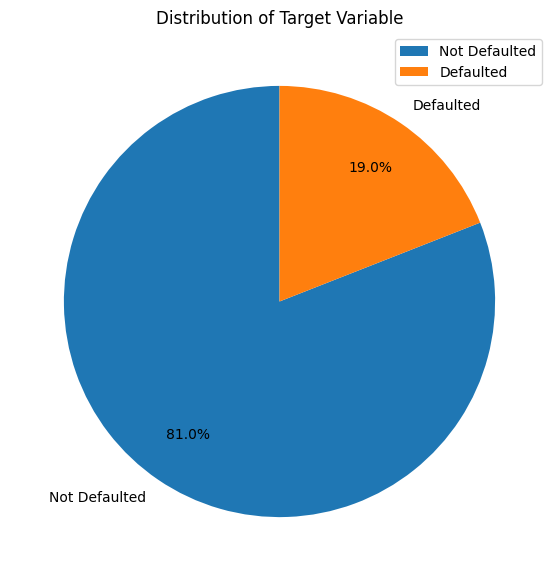

In [145]:
fig = plt.figure(figsize=(10, 7))

plt.pie(
    df_train_clean["next_month_default"].value_counts(),
    labels=["Not Defaulted", "Defaulted"],
    autopct='%1.1f%%',      # show percentage
    startangle=90,          # rotate for nicer view
    pctdistance=0.75,       # position of percentage text
    labeldistance=1.1       # position of labels
)

plt.title("Distribution of Target Variable")
plt.legend(["Not Defaulted", "Defaulted"])
plt.show()

Out of the 25,000 customers in the dataset, 19% defaulted within one month, indicating a class imbalance that must be taken into account during the modelling process.

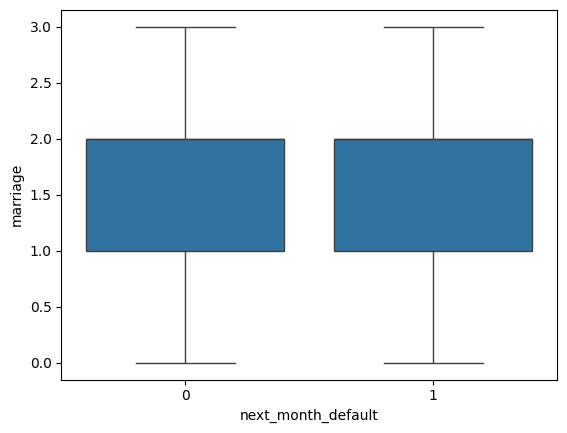

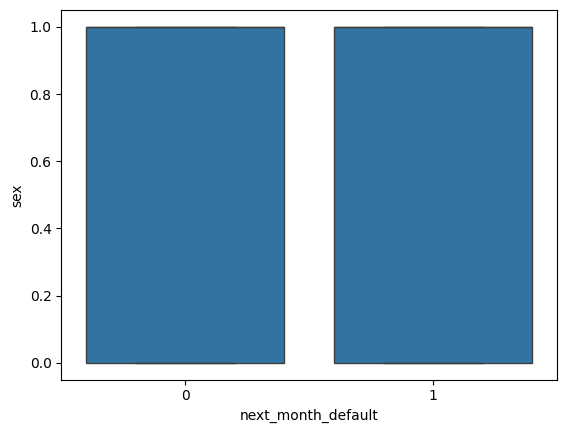

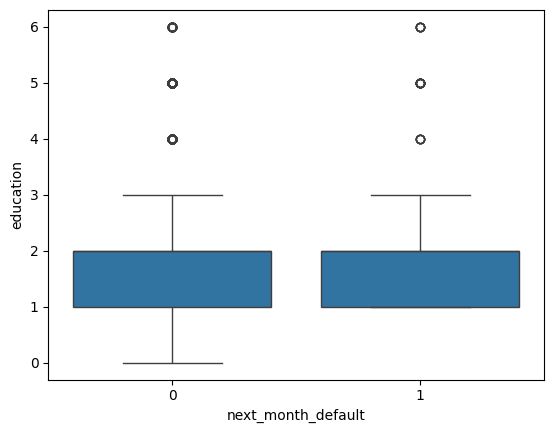

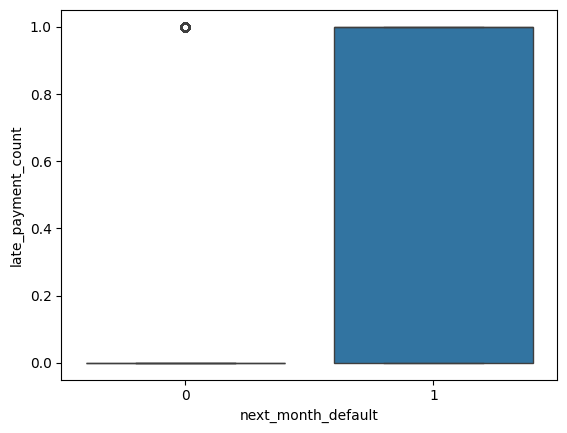

In [150]:
# Distribution of age (box plot)

for x in ["marriage", "sex", "education", "late_payment_count"]:
    boxplot = sns.boxplot(x="next_month_default", y=x, data=df_train_clean)
    plt.show()

No significant differences were detected between the default and non-default groups with regard to education, marital status, and sex. However, customers who are unable to repay in the following month tend to have a history of late payments.

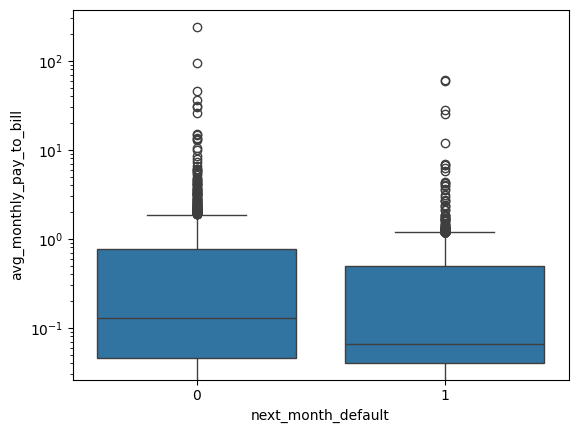

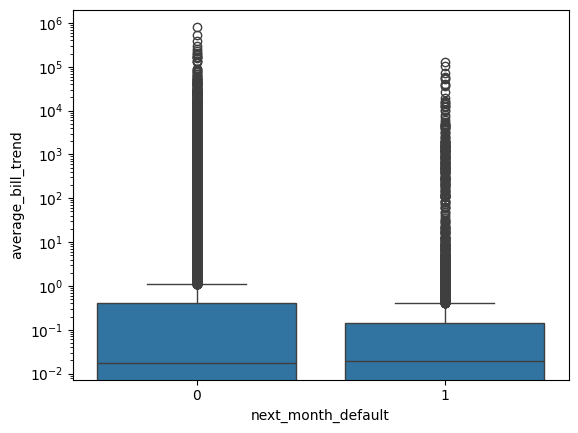

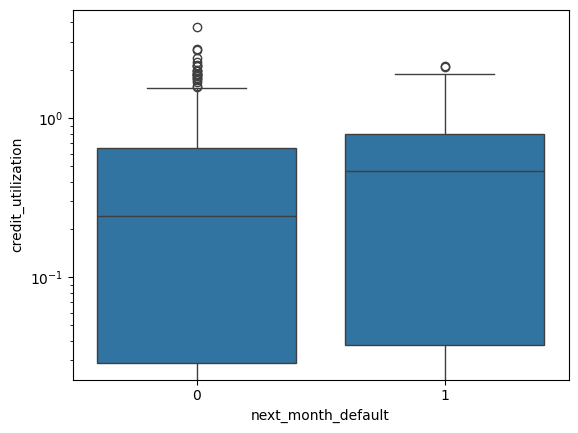

In [154]:
for x in ["avg_monthly_pay_to_bill", "average_bill_trend", "credit_utilization"]:
    boxplot = sns.boxplot(x="next_month_default", y=x, data=df_train_clean)
    plt.yscale("log")  # Set x-axis limits to focus on the box plot
    plt.show()

According to the box plots, customers who default within one month tend to make lower payments relative to their bill amounts and also tend to utilize a larger proportion of their credit limits.

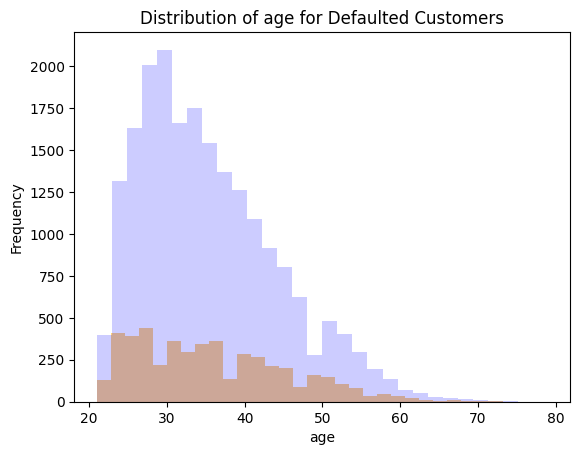

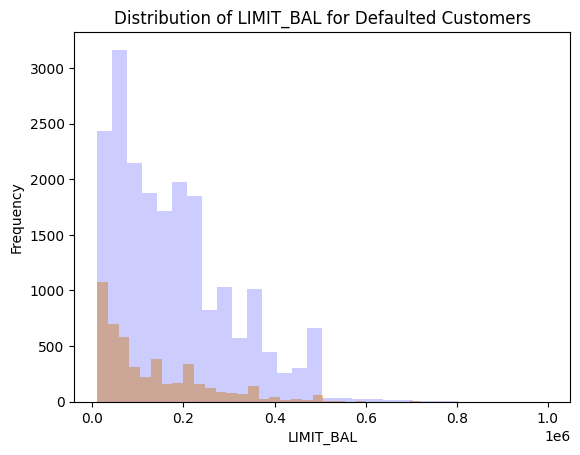

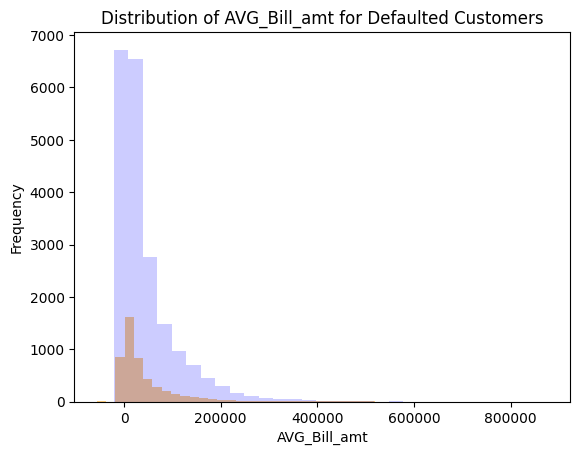

In [148]:
for x in ["age", "LIMIT_BAL", "AVG_Bill_amt"]:
    plt.hist(df_train_clean[df_train_clean["next_month_default"] == 1][x], bins=30, color = "orange", alpha=0.5)
    plt.hist(df_train_clean[df_train_clean["next_month_default"] == 0][x], bins=30, color = "blue", alpha=0.2)
    plt.xlabel(x)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {x} for Defaulted Customers")
    plt.show()

However, customers who are likely to default and those who are not show no substantial differences in age, credit limit, or average bill amount.

### 5. Modelling

#### Preprocessing

In this section, we develop three models: XGBoost, Random Forest, and a Neural Network, to predict customer default in the following month. The F1-score is selected as the primary evaluation metric because it balances precision and recall, making it suitable for imbalanced classification problems. When models achieve similar F1-scores, recall is used as the secondary criterion for model selection.

In [59]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [48]:
# Split testing and training(validation) data
X_train, X_val, y_train, y_val = train_test_split(X , y , stratify = y, test_size = 0.2, random_state = 42)

In [12]:
features = X.columns

First, a preprocessing pipeline is defined for the models. For the tree-based models, class imbalance is addressed and variables showing little or no difference between the default and non-default groups are removed.

In [ ]:
# Define preprocessing step
trees_preprocessor = ColumnTransformer(
    [
        ("zv_filter", VarianceThreshold(1e-4), features)
    ],
    remainder='passthrough' # Pass through numerical features unscaled
)

In [ ]:
# counts the number of classes before oversampling
print('Before balancing:', Counter(y_train))

# defines the resampler
resampler = SMOTETomek(random_state=42, n_jobs=-1)

# transforms the data set
X_balanced, y_balanced = resampler.fit_resample(X_train, y_train)

# counts the number of classes after oversampling
print('After balancing:', Counter(y_balanced))

Before balancing: Counter({0: 16352, 1: 3845})
After balancing: Counter({0: 14777, 1: 14777})


#### XGBoost

In [81]:
# 1. XGBoost classifier
#cale_pos_weight = (len(y_balanced) - sum(y_balanced))/sum(y_balanced) # handle class imbalance

xgb_model = XGBClassifier(
    objective="binary:logistic",
    #scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    use_label_encoder=False
)


In [82]:
# 2. Pipeline
pipeline = Pipeline(steps=
 [
    ("preprocess", trees_preprocessor),
    ("model", xgb_model)
])


In [83]:
# 3. Hyperparameter
params = {
    "model__n_estimators": [300, 500, 700],
    #"model__scale_pos_weight": [scale_pos_weight],
    "model__max_depth": [3, 5, 7],
    "model__min_child_weight": [3, 5, 7],
    "model__gamma": [0, 0.1, 0.3, 0.5],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__learning_rate": [0.01, 0.05, 0.1]
}

In [84]:
# 4. Cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=9)
#scorer = make_scorer(roc_auc_score, needs_proba=True)

In [85]:
# 5. Hyperparameter tuning
search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=params,
    n_iter=20,  # like size=20 in R
    scoring='f1',
    cv=cv,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

In [86]:
# 6. Fit model
search.fit(X_balanced, y_balanced)

Fitting 10 folds for each of 20 candidates, totalling 200 fits


c:\Users\nguye\Creditscoring\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:29:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.6, 0.8, ...], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies 

In [87]:
# 7. Best parameters
print("Best parameters:", search.best_params_)
print("Best f1:", search.best_score_)


Best parameters: {'model__n_estimators': 500, 'model__min_child_weight': 3, 'model__max_depth': 7, 'model__learning_rate': 0.1, 'model__gamma': 0.1, 'model__colsample_bytree': 0.8}
Best f1: 0.8768968728793565


In [88]:
# 8. Final model
xgb_model = search.best_estimator_

In [89]:
# Predict on validation set

# Predict class labels
y_pred_xgb = xgb_model.predict(X_val)

# Predict probabilities (for ROC-AUC)
y_val_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]  # probability for class 1
y_train_proba_xgb = xgb_model.predict_proba(X_balanced)[:, 1]

Accuracy: 0.8162376237623762
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.91      0.89      4088
           1       0.52      0.42      0.46       962

    accuracy                           0.82      5050
   macro avg       0.70      0.66      0.68      5050
weighted avg       0.80      0.82      0.81      5050

AUC training: 0.9963
AUC validation: 0.7503


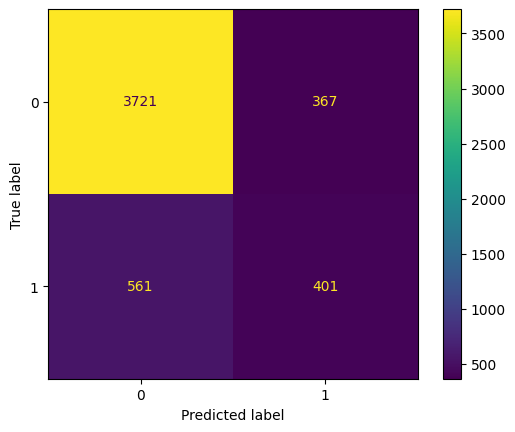

In [90]:
# Evaluate model

# Accuracy
accuracy = accuracy_score(y_true = y_val, y_pred = y_pred_xgb)
print("Accuracy:", accuracy)

# Classification report (precision, recall, F1-score)
print("Classification Report:\n", classification_report(y_true = y_val, y_pred = y_pred_xgb))

# ROC-AUC
auc_score_train = roc_auc_score(y_balanced, y_train_proba_xgb)
auc_score_val = roc_auc_score(y_val, y_val_proba_xgb)
print(f"AUC training: {auc_score_train:.4f}")
print(f"AUC validation: {auc_score_val:.4f}")

# Confusion matrix
cm = confusion_matrix(y_true = y_val, y_pred = y_pred_xgb, labels = xgb_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels= xgb_model.classes_)
disp.plot()
plt.show()

                      Feature  Importance
6                       pay_2   50.534912
0                    marriage   21.644854
5                       pay_0   19.876974
1                         sex   18.633284
7                       pay_3   13.982604
8                       pay_4   12.424993
4                         age   12.162943
2                   education   10.974865
10                      pay_6   10.352228
9                       pay_5    8.603605
12         late_payment_count    7.174626
14            average_payment    4.911507
3                   LIMIT_BAL    4.288975
11               AVG_Bill_amt    3.958063
17         credit_utilization    3.852070
16  average_pay_to_bill_trend    3.418498
15    avg_monthly_pay_to_bill    3.391809
13         average_bill_trend    3.223394


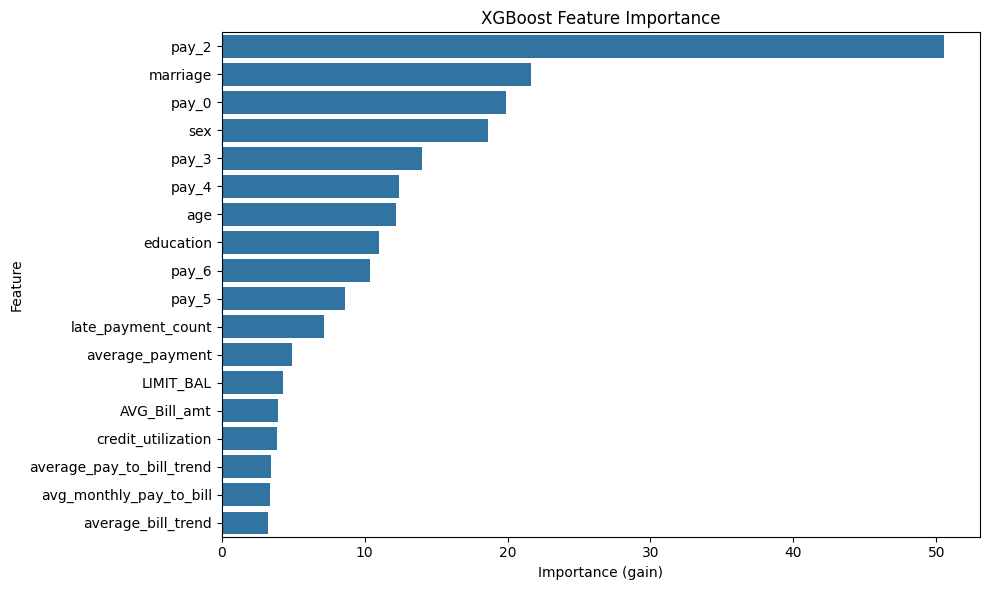

In [91]:
# Feature importance
# 1. Extract fitted XGBClassifier
xgb_model_fitted = xgb_model.named_steps['model']

# 3. Feature importance
importance_dict = xgb_model_fitted.get_booster().get_score(importance_type='gain')

# 4. Map 'f0', 'f1', ... to real feature names
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': list(importance_dict.values())
}).sort_values(by='Importance', ascending=False)

print(importance_df)

# 5. Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance (gain)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#### Random forest

In [92]:
rf = RandomForestClassifier(criterion='gini',
                            random_state=42,
                            class_weight='balanced')

In [93]:

# 2. Pipeline
pipeline = Pipeline(steps=[
    ("preprocess", trees_preprocessor), # Use the new specific preprocessor
    ("model", rf)
])

In [94]:
# 3. Hyperparameter
param_dist = {
    'model__n_estimators': randint(100, 300),
    'model__max_depth': randint(3, 15),
    'model__min_samples_split': randint(2, 10),
    'model__min_samples_leaf': randint(1, 5),
    'model__max_features': randint(1,6),
}

In [95]:
# 4. Cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=9)

In [104]:
# 5. Hyperparameter tuning
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='average_precision',
    cv=cv,
    verbose=2,
    n_jobs=-1,
    random_state=42
)


In [105]:
# 6. Fit model
random_search.fit(X_balanced, y_balanced)

Fitting 10 folds for each of 20 candidates, totalling 200 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': <scipy.stats....001F790085E50>, 'model__max_features': <scipy.stats....001F7900949D0>, 'model__min_samples_leaf': <scipy.stats....001F78EBB4A50>, 'model__min_samples_split': <scipy.stats....001F78EAAD610>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be th

In [106]:
# 7. Best parameters
print("Best Parameters:\n", random_search.best_params_)
print("Best average precision:", random_search.best_score_)

# 8. Final model
rf_model = random_search.best_estimator_

Best Parameters:
 {'model__max_depth': 14, 'model__max_features': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 157}
Best average precision: 0.9185164137900333


In [107]:
# Predict on validation set

# Predict class labels
y_pred_rf = rf_model.predict(X_val)

# Predict probabilities (for ROC-AUC)
y_val_proba_rf = rf_model.predict_proba(X_val)[:, 1]
y_train_proba_rf = rf_model.predict_proba(X_balanced)[:, 1]

Accuracy: 0.7914851485148515
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.86      0.87      4088
           1       0.46      0.51      0.48       962

    accuracy                           0.79      5050
   macro avg       0.67      0.68      0.68      5050
weighted avg       0.80      0.79      0.80      5050

AUC training: 0.9746
AUC validation: 0.7584


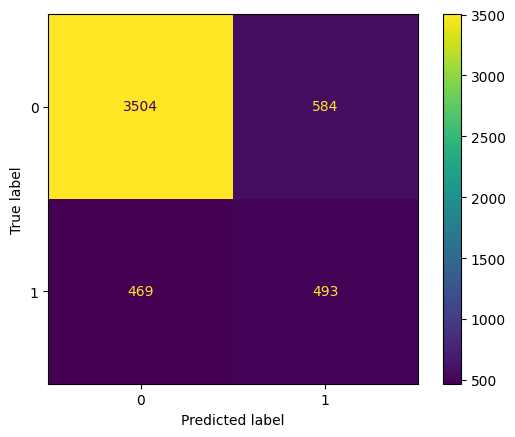

In [108]:
# Accuracy
accuracy = accuracy_score(y_true = y_val, y_pred = y_pred_rf)
print("Accuracy:", accuracy)

# Classification report (precision, recall, F1-score)
print("Classification Report:\n", classification_report(y_true = y_val, y_pred = y_pred_rf))

# ROC-AUC
auc_score_train = roc_auc_score(y_balanced, y_train_proba_rf)
auc_score_val = roc_auc_score(y_val, y_val_proba_rf)
print(f"AUC training: {auc_score_train:.4f}")
print(f"AUC validation: {auc_score_val:.4f}")

# Confusion matrix
cm = confusion_matrix(y_val, y_pred_rf, labels=rf_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot()
plt.show()

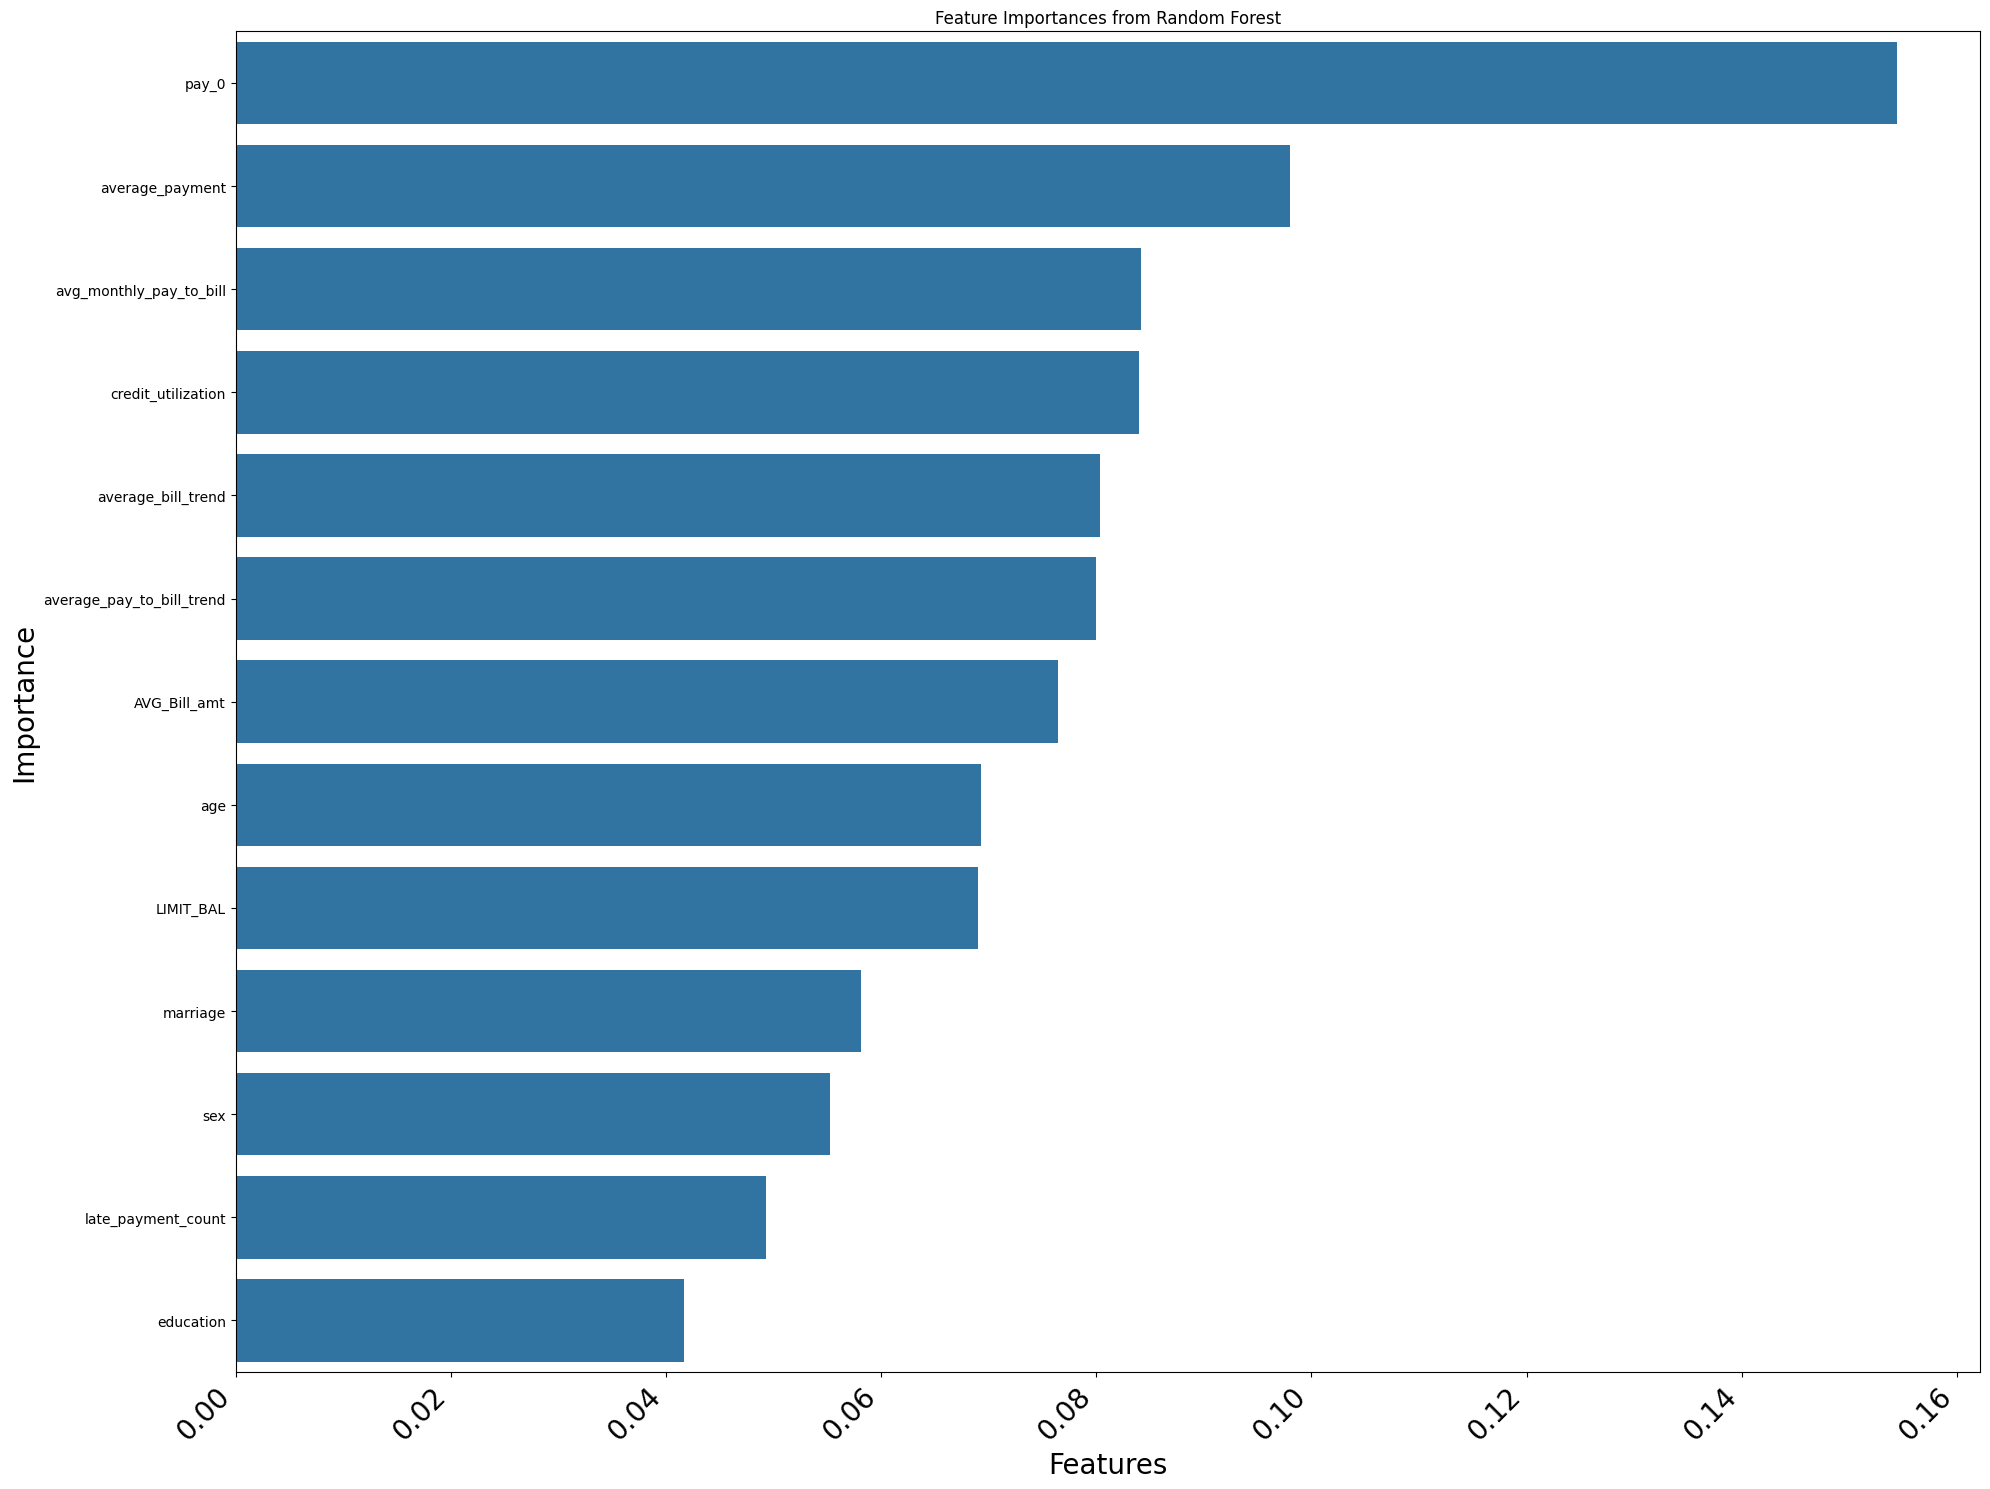

In [92]:
# Feature importance
# Access the RandomForestClassifier model from the pipeline
rf_model_fitted = rf_model.named_steps['model']

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model_fitted.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_df

plt.figure(figsize=(20, 15))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances from Random Forest')
plt.xlabel('Features', size = 20)
plt.ylabel('Importance', size = 20)
plt.xticks(rotation=45, ha='right', size = 20)
plt.tight_layout()
plt.show()

#### Neural Network

For the neural network model, numerical variables are scaled because neural networks are sensitive to differences in variable scale.

In [49]:
# Define preprocessing steps
num_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('zv_filter', VarianceThreshold(1e-4))
])
preprocessing = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, features),
    ]
)

In [56]:
# Preprocess features
X_train_scaled = preprocessing.fit_transform(X_train)
X_val_scaled = preprocessing.transform(X_val)

In [117]:
# 1. Neural Network Classifier
nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(16, activation='relu'),
    BatchNormalization(),

    Dense(1, activation='sigmoid')  # binary classification
])

# 2. Pipeline

# 3. Hyperparameter (fixed for NN)
# (Neural networks do not use param grids like scikit-learn models)

# 4. Cross-validation
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
# 5. Hyperparameter tuning
# (NN does not use GridSearchCV; tuning based on training)

# Add class imbalance handling (same effect as SVC class_weight="balanced")
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {i: class_weights[i] for i in range(len(class_weights))}
print("Class weights:", class_weights)

# 6. Fit model
nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        keras.metrics.BinaryAccuracy(name='accuracy'),
        keras.metrics.AUC(name='auc'),
        keras.metrics.F1Score(
            threshold=0.5,
            average='micro',
            name='f1'
        )
    ]
)

history = nn_model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_scaled, y_val),
    callbacks=[early_stopping],
    verbose=2,
    class_weight=class_weights         # << class imbalance
)


# 7. Best parameters
print("Best parameters: Neural network uses fixed architecture (no param grid).")
print("Best F1-Score:", max(history.history['val_f1']))

# 8. Final model
nn_model

c:\Users\nguye\Creditscoring\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Class weights: {0: 0.6175697162426614, 1: 2.6263979193758127}
Epoch 1/100
632/632 - 10s - 15ms/step - accuracy: 0.6554 - auc: 0.6863 - f1: 0.4070 - loss: 0.6554 - val_accuracy: 0.7521 - val_auc: 0.7558 - val_f1: 0.4939 - val_loss: 0.5950
Epoch 2/100
632/632 - 2s - 4ms/step - accuracy: 0.7208 - auc: 0.7335 - f1: 0.4598 - loss: 0.6033 - val_accuracy: 0.7374 - val_auc: 0.7696 - val_f1: 0.4876 - val_loss: 0.6014
Epoch 3/100
632/632 - 2s - 4ms/step - accuracy: 0.7350 - auc: 0.7469 - f1: 0.4730 - loss: 0.5914 - val_accuracy: 0.7515 - val_auc: 0.7749 - val_f1: 0.4937 - val_loss: 0.5814
Epoch 4/100
632/632 - 2s - 4ms/step - accuracy: 0.7344 - auc: 0.7536 - f1: 0.4717 - loss: 0.5850 - val_accuracy: 0.7612 - val_auc: 0.7763 - val_f1: 0.5004 - val_loss: 0.5701
Epoch 5/100
632/632 - 2s - 4ms/step - accuracy: 0.7422 - auc: 0.7615 - f1: 0.4810 - loss: 0.5787 - val_accuracy: 0.7608 - val_auc: 0.7802 - val_f1: 0.5025 - val_loss: 0.5585
Epoch 6/100
632/632 - 2s - 4ms/step - accuracy: 0.7462 - auc: 0.76

<Sequential name=sequential_4, built=True>

In [118]:
# Prediction
y_val_proba_nn = nn_model.predict(X_val_scaled).ravel()
y_train_proba_nn = nn_model.predict(X_train_scaled).ravel()
y_pred_nn = (y_val_proba_nn > 0.5).astype(int)

158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
632/632 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [119]:
y_val_proba_nn

array([0.37634283, 0.19512779, 0.41837493, ..., 0.46520305, 0.11305074,
       0.3257306 ], dtype=float32)

In [120]:
# Evaluate model
accuracy = accuracy_score(y_val, y_pred_nn)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_val, y_pred_nn)
print("Confusion Matrix:\n", cm)

print("Classification Report:\n", classification_report(y_val, y_pred_nn))

roc_auc_train = roc_auc_score(y_train, y_train_proba_nn)
roc_auc_val = roc_auc_score(y_val, y_val_proba_nn)
print("ROC-AUC training:", roc_auc_train)
print("ROC-AUC validation:", roc_auc_val)

Accuracy: 0.7706930693069307
Confusion Matrix:
 [[3293  795]
 [ 363  599]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.81      0.85      4088
           1       0.43      0.62      0.51       962

    accuracy                           0.77      5050
   macro avg       0.67      0.71      0.68      5050
weighted avg       0.81      0.77      0.79      5050

ROC-AUC training: 0.7960979548756995
ROC-AUC validation: 0.7872660359817895


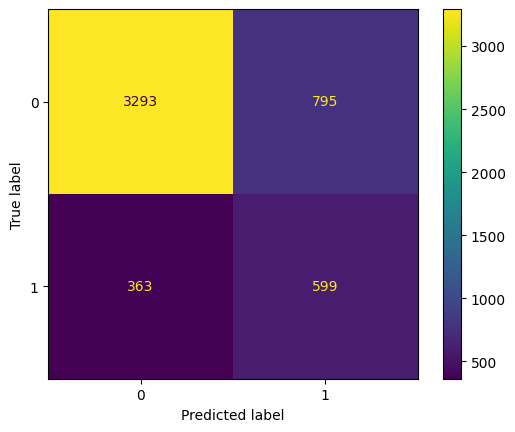

In [121]:
# Visualization of confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

As discussed, the neural network model was selected as the best-performing model based on the F1-score and recall for the “Default” class. The model and preprocessing pipeline will be saved and integrated into the credit scoring tool.

In [122]:
nn_model.save("nn_model.keras")

In [123]:

joblib.dump(preprocessing, "preprocessing.pkl")

['preprocessing.pkl']

### 6. Expected loss and Risk management

#### 6.1. Expected loss function

From the selected model, the distribution of expected loss will be estimated. We assume that in the event of default, customers are able to repay only 20% of the outstanding amount, implying a Loss Given Default (LGD) of 0.8.

The expected next-month bill is calculated as the product of the bill trend and the previous month’s bill. Exposure at Default (EAD) is defined as the minimum of the predicted next-month bill and the available credit limit. The Probability of Default (PD) is provided by the trained model.

In [124]:

# Calculate exposure at default (EAD)
df_train_clean["next_bill"] = (1+df_train_clean["average_bill_trend"]) * df_train_clean["Bill_amt6"]
df_train_clean["EAD"] = np.where(df_train_clean["next_bill"] > df_train_clean["LIMIT_BAL"], df_train_clean["LIMIT_BAL"], df_train_clean["next_bill"])


In [125]:
# Caulate probability of default (PD)
X_scale = preprocessing.transform(X)
df_train_clean["PD"] = nn_model.predict(X_scale).ravel()

789/789 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [126]:
df_train_clean["PD"]

0        0.860048
1        0.392040
2        0.273307
3        0.137290
4        0.212667
           ...   
25242    0.416713
25243    0.454659
25244    0.445716
25245    0.225752
25246    0.491786
Name: PD, Length: 25247, dtype: float32

In [127]:
# Calculate expected loss (EL)
LGD = 0.8
df_train_clean["EL"] = df_train_clean["EAD"] * df_train_clean["PD"] * LGD
df_train_clean["EL"]

0        11861.654040
1        90953.324795
2        11821.331293
3         8173.096832
4            0.798768
             ...     
25242    30003.361702
25243     6229.951435
25244     8777.805429
25245    36065.633564
25246      567.755718
Name: EL, Length: 25247, dtype: float64

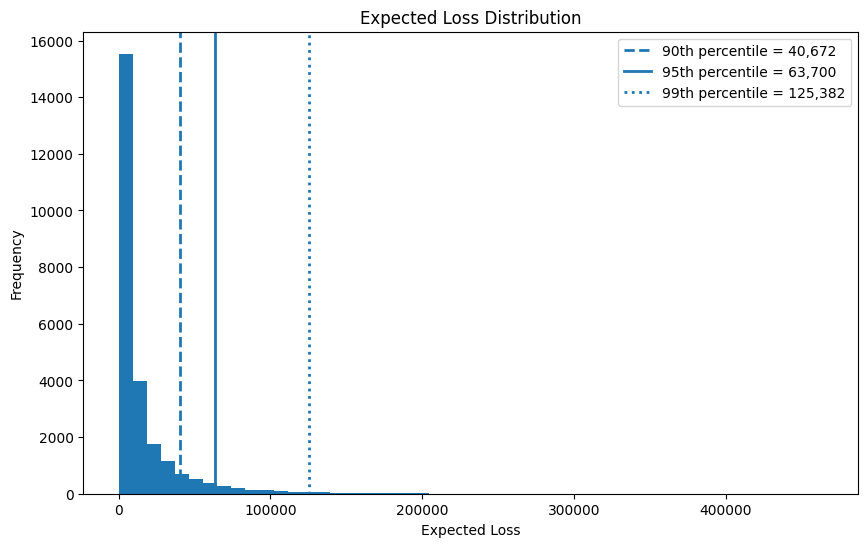

In [128]:
p90_EL = df_train_clean["EL"].quantile(0.90)
p95_EL = df_train_clean["EL"].quantile(0.95)
p99_EL = df_train_clean["EL"].quantile(0.99)

plt.figure(figsize=(10,6))

plt.hist(df_train_clean["EL"], bins=50)

plt.axvline(
    p90_EL,
    linestyle='--',
    linewidth=2,
    label=f'90th percentile = {p90_EL:,.0f}'
)

plt.axvline(
    p95_EL,
    linestyle='-',
    linewidth=2,
    label=f'95th percentile = {p95_EL:,.0f}'
)

plt.axvline(
    p99_EL,
    linestyle=':',
    linewidth=2,
    label=f'99th percentile = {p99_EL:,.0f}'
)

plt.xlabel("Expected Loss")
plt.ylabel("Frequency")
plt.title("Expected Loss Distribution")
plt.legend()

plt.show()

The expected loss distribution is highly right-skewed, with a long tail indicating the potential for large losses in extreme cases. The 95th percentile is approximately 64,000, while the 99th percentile rises sharply to 125,000. This substantial gap highlights the importance of implementing strategies to mitigate tail risk and manage potential high-loss scenarios.

#### 6.2. Risk management strategy

##### Threshold and Probability of Default

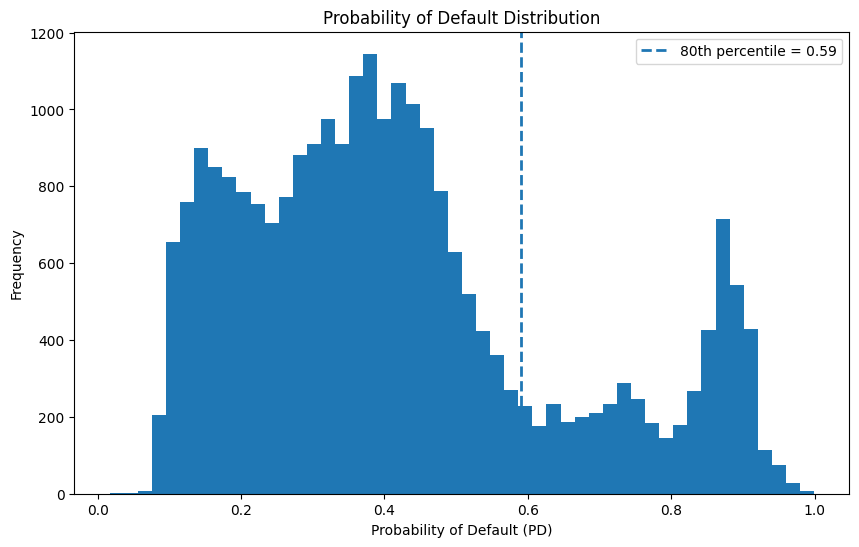

In [129]:
# Check distribution of PD
p80_PD = df_train_clean["PD"].quantile(0.80)

plt.figure(figsize=(10,6))

plt.hist(df_train_clean["PD"], bins=50)

plt.axvline(
    p80_PD,
    linestyle='--',
    linewidth=2,
    label=f'80th percentile = {p80_PD:,.2f}'
)

plt.xlabel("Probability of Default (PD)")
plt.ylabel("Frequency")
plt.title("Probability of Default Distribution")
plt.legend()

plt.show()

In [130]:
p80 = df_train_clean["PD"].quantile(0.80)
detected = df_train_clean.loc[df_train_clean["PD"] > p80, "next_month_default"].sum()
total = df_train_clean["next_month_default"].sum()

print(f"Detect {detected} out of {total}")


Detect 2561 out of 4807


From the distribution of predicted default probabilities, different classification thresholds are explored. Using a threshold set at the 80th percentile, approximately 53% of defaulting customers can be correctly identified.

In the next step, 20 threshold values ranging from 0 to 0.95 will be tested to evaluate their impact on the F1-score and recall.

In [140]:
for threshold in np.arange(0.00, 1.00, 0.05):
    y_pred_threshold = (df_train_clean["PD"] > threshold).astype(int)
    f1 = f1_score(df_train_clean["next_month_default"], y_pred_threshold)
    recall = recall_score(df_train_clean["next_month_default"], y_pred_threshold)
    print(f"Threshold: {threshold:.2f}, F1_score: {f1:.2f}, Recall: {recall:.2f}")

Threshold: 0.00, F1_score: 0.32, Recall: 1.00
Threshold: 0.05, F1_score: 0.32, Recall: 1.00
Threshold: 0.10, F1_score: 0.32, Recall: 1.00
Threshold: 0.15, F1_score: 0.34, Recall: 0.99
Threshold: 0.20, F1_score: 0.36, Recall: 0.97
Threshold: 0.25, F1_score: 0.38, Recall: 0.95
Threshold: 0.30, F1_score: 0.41, Recall: 0.91
Threshold: 0.35, F1_score: 0.43, Recall: 0.86
Threshold: 0.40, F1_score: 0.46, Recall: 0.79
Threshold: 0.45, F1_score: 0.50, Recall: 0.71
Threshold: 0.50, F1_score: 0.51, Recall: 0.62
Threshold: 0.55, F1_score: 0.52, Recall: 0.57
Threshold: 0.60, F1_score: 0.52, Recall: 0.53
Threshold: 0.65, F1_score: 0.52, Recall: 0.50
Threshold: 0.70, F1_score: 0.51, Recall: 0.47
Threshold: 0.75, F1_score: 0.50, Recall: 0.42
Threshold: 0.80, F1_score: 0.47, Recall: 0.37
Threshold: 0.85, F1_score: 0.42, Recall: 0.31
Threshold: 0.90, F1_score: 0.19, Recall: 0.11
Threshold: 0.95, F1_score: 0.02, Recall: 0.01


To balance F1-score and recall, a threshold of 0.45 is selected. At this threshold, approximately 71% of default customers are correctly identified, while the F1-score remains largely unaffected.

##### Loss Given Default

In [153]:
df_train_clean[df_train_clean["next_bill"] >= df_train_clean["LIMIT_BAL"]]["next_month_default"].sum()

496

Out of 4807 default customers, 496 customers reached their credit limit.

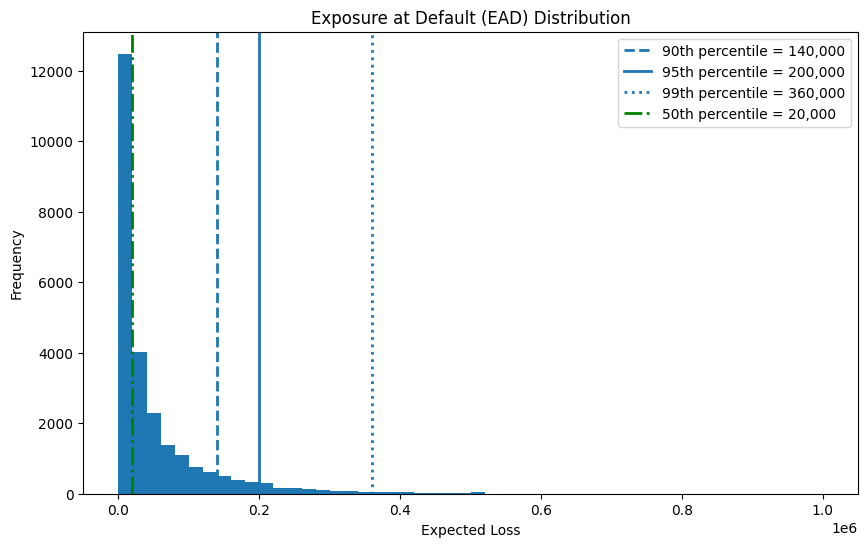

In [133]:
# Check distribution of EAD
p90_EAD = df_train_clean["EAD"].quantile(0.90)
p95_EAD = df_train_clean["EAD"].quantile(0.95)
p99_EAD = df_train_clean["EAD"].quantile(0.99)
p50_EAD = df_train_clean["EAD"].quantile(0.50)

plt.figure(figsize=(10,6))

plt.hist(df_train_clean["EAD"], bins=50)

plt.axvline(
    p90_EAD,
    linestyle='--',
    linewidth=2,
    label=f'90th percentile = {p90_EAD:,.0f}'
)

plt.axvline(
    p95_EAD,
    linestyle='-',
    linewidth=2,
    label=f'95th percentile = {p95_EAD:,.0f}'
)

plt.axvline(
    p99_EAD,
    linestyle=':',
    linewidth=2,
    label=f'99th percentile = {p99_EAD:,.0f}'
)

plt.axvline(
    p50_EAD,
    linestyle='-.',
    linewidth=2,
    color = 'green',
    label=f'50th percentile = {p50_EAD:,.0f}'
)

plt.xlabel("Expected Loss")
plt.ylabel("Frequency")
plt.title("Exposure at Default (EAD) Distribution")
plt.legend()

plt.show()

Exposure at Default is also highly right-skewed, with a long right tail. While the median is around 20,000, the 95th percentile reaches 200,000. Based on this distribution, a threshold at the 95th percentile is selected. So that exposures in the extreme tail of the distribution can be explicitly identified and controlled, allowing for more effective management of potential large-loss cases.

##### Strategy

In practice, since other components of the expected loss cannot be directly controlled, we focus on managing credit limit as a lever to influence Exposure at Default (EAD).
We set an exposure threshold at the 95th percentile, corresponding to 200,000, and a probability of default cutoff of 0.4. Based on these criteria, customers are classified into two groups: high risk and low risk. High-risk customers are those whose predicted probability of default exceeds 0.4 or whose projected next bill or their credit limit exceeds 200,000.

In [134]:
df_train_clean["class"] = np.where((df_train_clean["PD"] >= 0.45) | (df_train_clean["EAD"] >= 200000), "High Risk",
                             "Low Risk")  

In [135]:
df_train_clean[df_train_clean["class"] == "High Risk"].count()/ df_train_clean.shape[0]

Customer_ID                  0.399176
marriage                     0.399176
sex                          0.399176
education                    0.399176
LIMIT_BAL                    0.399176
age                          0.399176
pay_0                        0.399176
pay_2                        0.399176
pay_3                        0.399176
pay_4                        0.399176
pay_5                        0.399176
pay_6                        0.399176
Bill_amt1                    0.399176
Bill_amt2                    0.399176
Bill_amt3                    0.399176
Bill_amt4                    0.399176
Bill_amt5                    0.399176
Bill_amt6                    0.399176
pay_amt1                     0.399176
pay_amt2                     0.399176
pay_amt3                     0.399176
pay_amt4                     0.399176
pay_amt5                     0.399176
pay_amt6                     0.399176
AVG_Bill_amt                 0.399176
PAY_TO_BILL_ratio            0.399176
next_month_d

In [136]:
df_train_clean[df_train_clean["class"] == "High Risk"].count()

Customer_ID                  10078
marriage                     10078
sex                          10078
education                    10078
LIMIT_BAL                    10078
age                          10078
pay_0                        10078
pay_2                        10078
pay_3                        10078
pay_4                        10078
pay_5                        10078
pay_6                        10078
Bill_amt1                    10078
Bill_amt2                    10078
Bill_amt3                    10078
Bill_amt4                    10078
Bill_amt5                    10078
Bill_amt6                    10078
pay_amt1                     10078
pay_amt2                     10078
pay_amt3                     10078
pay_amt4                     10078
pay_amt5                     10078
pay_amt6                     10078
AVG_Bill_amt                 10078
PAY_TO_BILL_ratio            10078
next_month_default           10078
late_payment_count           10078
bill_trend1         

With this classification, 40% of the customers are classified as high risk

In [137]:
df_train_clean[df_train_clean["class"] == "High Risk"]["next_month_default"].sum()/df_train_clean["next_month_default"].sum()   

0.7312252964426877

With this setup, 73.12% of customers who default in the following month are classified as “High Risk” in the current month. For these customers, the credit limit can then be adjusted, ranging from a reduction of 5% up to 50%.

We then evaluate the impact of using the 95th and 99th percentiles of expected loss as alternative thresholds to assess how they affect risk segmentation and portfolio outcomes.

In [138]:
for i in np.arange(0.5, 1, 0.05):
    df_train_clean["new_LMIT"] = np.where(
        df_train_clean["class"] == "High Risk",
        df_train_clean["LIMIT_BAL"] * i,
        df_train_clean["LIMIT_BAL"]
    )
    df_train_clean["new_EAD"] = np.where(
        df_train_clean["next_bill"] > df_train_clean["new_LMIT"],
        df_train_clean["new_LMIT"],
        df_train_clean["next_bill"],
    )
    df_train_clean["new_EL"] = df_train_clean["new_EAD"] * df_train_clean["PD"] * LGD
    new_p95 = df_train_clean["new_EL"].quantile(0.95)
    new_p99 = df_train_clean["new_EL"].quantile(0.99)
    reduce_95 = (( new_p95 - p95_EL ) / p95_EL) * 100
    reduce_99 = (( new_p99 - p99_EL ) / p99_EL) * 100
    print(f"i = {i:.2f}, 95th percentile of Expected Loss changes: {reduce_95:.2f}%, 99th percentile of Expected Loss changes: {reduce_99:.2f}%")



i = 0.50, 95th percentile of Expected Loss changes: -28.92%, 99th percentile of Expected Loss changes: -38.81%
i = 0.55, 95th percentile of Expected Loss changes: -25.70%, 99th percentile of Expected Loss changes: -33.23%
i = 0.60, 95th percentile of Expected Loss changes: -22.14%, 99th percentile of Expected Loss changes: -28.09%
i = 0.65, 95th percentile of Expected Loss changes: -18.67%, 99th percentile of Expected Loss changes: -23.29%
i = 0.70, 95th percentile of Expected Loss changes: -14.99%, 99th percentile of Expected Loss changes: -18.99%
i = 0.75, 95th percentile of Expected Loss changes: -11.97%, 99th percentile of Expected Loss changes: -14.00%
i = 0.80, 95th percentile of Expected Loss changes: -8.82%, 99th percentile of Expected Loss changes: -9.55%
i = 0.85, 95th percentile of Expected Loss changes: -5.91%, 99th percentile of Expected Loss changes: -6.65%
i = 0.90, 95th percentile of Expected Loss changes: -3.15%, 99th percentile of Expected Loss changes: -3.56%
i = 0.9

A 25% reduction in credit exposure for the high-risk group leads to substantial decreases in expected loss. Specifically, the 95th percentile of expected loss decreases by 11.97%, while the 99th percentile decreases by 14%. This approach helps limit extreme downside scenarios in expected loss and improves control over credit default risk exposure.

In [168]:
i = 0.75
df_train_clean["new_LIMIT"] = np.where(
        df_train_clean["class"] == "High Risk",
        df_train_clean["LIMIT_BAL"] * i,
        df_train_clean["LIMIT_BAL"]
    )

df_train_clean["new_EAD"] = np.where(
    df_train_clean["next_bill"] > df_train_clean["new_LIMIT"],
    df_train_clean["new_LIMIT"],
    df_train_clean["next_bill"],
)
df_train_clean["new_EL"] = df_train_clean["new_EAD"] * df_train_clean["PD"] * LGD
new_p95 = df_train_clean["new_EL"].quantile(0.95)
new_p99 = df_train_clean["new_EL"].quantile(0.99)
print(f"i = {i:.2f}, 95th percentile of Expected Loss: {new_p95:.2f}, 99th percentile of Expected Loss: {new_p99:.2f}")

i = 0.75, 95th percentile of Expected Loss: 56073.90, 99th percentile of Expected Loss: 107834.76


By reducing the credit limit of high-risk customers by 25%, in 99% of the cases, the expected loss does not excess € 107,835, which was € 125,204 before.

Another approach is to penalize customers with late payments by reducing their credit limits, as late payment behavior is one of the strongest indicators of future default. Under this strategy, the credit limit is reduced by 10% for each month in which a customer makes a late payment.

In [169]:
df_train_clean["late_payment_months"] = (
    df_train_clean[[f"pay_{i}" for i in [0, 2, 3, 4, 5, 6]]] >= 1
).sum(axis=1)


In [170]:
df_train_clean["new_limit_late"] = df_train_clean["LIMIT_BAL"] - df_train_clean["late_payment_months"] * 0.1 * df_train_clean["LIMIT_BAL"]
df_train_clean["new_limit_late"] = df_train_clean["new_limit_late"].clip(lower=0)  # Ensure limit doesn't go negative

In [171]:
df_train_clean["new_EAD_late"] = np.where(
    df_train_clean["next_bill"] > df_train_clean["new_limit"],
    df_train_clean["new_limit_late"],
    df_train_clean["next_bill"],
)
df_train_clean["new_EL2"] = df_train_clean["new_EAD_late"] * df_train_clean["PD"] * LGD
new_p95_late = df_train_clean["new_EL2"].quantile(0.95)
new_p99_late = df_train_clean["new_EL2"].quantile(0.99)
reduce_95_late = (( new_p95_late - p95_EL ) / p95_EL) * 100
reduce_99_late = (( new_p99_late - p99_EL ) / p99_EL) * 100
print(f"95th percentile of Expected Loss: {new_p95_late:.2f}, 99th percentile of Expected Loss: {new_p99_late:.2f}")
print(f"95th percentile of Expected Loss changes: {reduce_95_late:.2f}%, 99th percentile of Expected Loss changes: {reduce_99_late:.2f}%")

95th percentile of Expected Loss: 57020.13, 99th percentile of Expected Loss: 108229.31
95th percentile of Expected Loss changes: -10.49%, 99th percentile of Expected Loss changes: -13.68%


The results are quite similar with the previous approach, with the 95th percentile of expected loss decreasing by 10.49% and the 99th percentile decreasing by 13.68%.

Considering both approaches, the second strategy may be more favorable, as it applies gradual adjustments based on customer payment behavior and is therefore less likely to negatively impact customer relationships.

Finally, classification can be used to identify high-risk customers and generate warnings within the system for further monitoring, such as: “This customer is classified as High Risk. Consider reducing credit limit and applying stricter credit terms."
However, actual credit limit reductions should primarily be based on repeated late payment behavior rather than solely on the model classification result.